# Pitch Count Workload

This notebook pulls pitch-level Statcast data from Baseball Savant, rolls it up to per-game pitcher pitch counts, and then looks for high-volume starters and workload consistency.


## Setup

Set the season, team list, request headers, and helper functions in one place so the later analysis cells can stay short.


In [1]:
from __future__ import annotations

from io import StringIO
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# Make imports/data paths stable whether the notebook is opened from the repo
# root or from notebooks/pitch_count.
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

YEAR = 2026
TEAMS = [
    "LAA", "HOU", "ATH", "TOR", "ATL", "MIL", "STL", "CHC", "AZ", "LAD",
    "SF", "CLE", "SEA", "MIA", "NYM", "WSH", "BAL", "SD", "PHI", "PIT",
    "TEX", "TB", "BOS", "CIN", "COL", "KC", "DET", "MIN", "CWS", "NYY",
]

REQUEST_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36"
    ),
    "X-Requested-With": "XMLHttpRequest",
}


In [2]:
def statcast_pitcher_url(team: str, year: int = YEAR) -> str:
    """Build the Baseball Savant CSV endpoint for regular-season pitcher pitches."""
    return (
        "https://baseballsavant.mlb.com/statcast_search/csv"
        "?all=true"
        "&hfGT=R%7C"
        f"&hfSea={year}%7C"
        "&player_type=pitcher"
        f"&hfTeam={team}"
        "&group_by=name"
        "&min_pitches=0&min_results=0&min_pas=0"
        "&sort_col=pitches&sort_order=desc"
        "&type=details"
    )


def fetch_pitch_details(team: str, year: int = YEAR) -> pd.DataFrame:
    """Download pitch-level Statcast rows for one team."""
    response = requests.get(
        statcast_pitcher_url(team, year),
        headers=REQUEST_HEADERS,
        timeout=60,
    )
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text), low_memory=False)


def pitch_counts_by_pitcher(df: pd.DataFrame) -> dict[str, dict[str, int]]:
    """Return {pitcher: {game_date: pitch_count}} for a team DataFrame."""
    grouped = df.groupby(["player_name", "game_date"]).size()
    return {
        pitcher: games.sort_index().astype(int).to_dict()
        for pitcher, games in grouped.groupby(level=0)
    }


def build_pitch_counts(teams: list[str], year: int = YEAR) -> dict[str, dict[str, dict[str, int]]]:
    """Fetch every team and keep the per-game pitch counts by pitcher."""
    pitch_counts: dict[str, dict[str, dict[str, int]]] = {}

    for team in teams:
        team_df = fetch_pitch_details(team, year)
        team_counts = pitch_counts_by_pitcher(team_df)
        pitch_counts[team] = team_counts
        print(team, np.array(sorted(team_counts)))

    return pitch_counts


def workload_rows(
    pitch_counts: dict[str, dict[str, dict[str, int]]],
    min_total_pitches: int,
) -> pd.DataFrame:
    """Summarize pitchers whose season pitch total clears the selected threshold."""
    rows = []
    for team in TEAMS:
        for pitcher, games in pitch_counts[team].items():
            counts = list(games.values())
            total_pitches = sum(counts)
            num_games = len(counts)
            avg_pitches = total_pitches / num_games if num_games else 0
            pitch_count_sd = float(np.std(counts)) if counts else 0

            if total_pitches > min_total_pitches:
                rows.append(
                    {
                        "team": team,
                        "pitcher": pitcher,
                        "total_pitches": total_pitches,
                        "num_games": num_games,
                        "avg_pitches": avg_pitches,
                        "pitch_count_sd": pitch_count_sd,
                    }
                )

    return pd.DataFrame(rows)


def print_workload_summary(summary: pd.DataFrame) -> None:
    """Print the compact workload line used throughout this notebook."""
    for row in summary.itertuples(index=False):
        print(
            f"Pitcher: {row.pitcher}, "
            f"Total Pitches: {row.total_pitches}, "
            f"Average Pitches: {np.round(row.avg_pitches, 0)}"
            f"+/-{np.round(row.pitch_count_sd, 0)}"
        )


## Data Pull

The smoke test fetches Toronto first. The full collection cell then loops through every team and stores results as `PitchCounts[team][pitcher][game_date] = pitch_count`.


In [3]:
# Quick smoke test before collecting every team.
DF = fetch_pitch_details("TOR", YEAR)
DF.head()


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,CH,2026-09-27,83.8,-3.28,5.23,"Scherzer, Max",665828,453286,walk,ball,...,NaN,2.93,1.42,-1.42,26.1,NaN,NaN,NaN,NaN,NaN
1,FF,2026-09-27,92.2,-3.19,5.39,"Scherzer, Max",665828,453286,NaN,ball,...,NaN,1.53,0.54,-0.54,27.4,NaN,NaN,NaN,NaN,NaN
2,CU,2026-09-27,72.8,-2.94,5.59,"Scherzer, Max",665828,453286,NaN,ball,...,NaN,5.07,-1.35,1.35,35.0,NaN,NaN,NaN,NaN,NaN
3,CH,2026-09-27,83.8,-3.22,5.47,"Scherzer, Max",665828,453286,NaN,ball,...,NaN,2.79,1.22,-1.22,29.2,NaN,NaN,NaN,NaN,NaN
4,CH,2026-09-27,83.9,-3.18,5.38,"Scherzer, Max",665828,453286,NaN,swinging_strike,...,NaN,2.92,1.31,-1.31,27.9,25.295956,-21.721155,30.970795,41.520831,44.275549


In [4]:
PitchCounts = build_pitch_counts(TEAMS, YEAR)


LAA ['Aldegheri, Sam' 'Anderson, Shaun' 'Bachman, Sam' 'Detmers, Reid'
 'Farris, Mitch' 'Fermin, José' 'Frazier, Adam' 'Fulmer, Michael'
 'Heineman, Tyler' 'Johnson, Ryan' 'Joyce, Ben' 'Kerry, Brett'
 'Kikuchi, Yusei' 'Klassen, George' 'Kochanowicz, Jack' 'Lucchesi, Joey'
 'Manoah, Alek' 'Martin, Trevor' 'Murphy, Luke' 'Natera Jr., Samy'
 'Peralta, Sammy' 'Pomeranz, Drew' 'Rodriguez, Grayson' 'Romano, Jordan'
 'Sandlin, Nick' 'Saucedo, Tayler' 'Silseth, Chase' 'Soriano, José'
 'Suter, Brent' 'Ureña, Walbert' 'Watson, Ryan' 'Weiman, Blake'
 'Yates, Kirby' 'Zeferjahn, Ryan']
HOU ['Abreu, Bryan' 'Alexander, Jason' 'Arrighetti, Spencer' 'Blanco, Ronel'
 'Blubaugh, AJ' 'Bolton, Cody' 'Brown, Hunter' 'Burrows, Mike'
 'De Los Santos, Enyel' 'France, J.P.' 'Gordon, Colton' 'Hader, Josh'
 'Hendrickson, Josh' 'Imai, Tatsuya' 'Javier, Cristian' 'King, Bryan'
 'Lambert, Peter' 'McCullers Jr., Lance' 'Meyers, Jake' 'Murray, Jayden'
 'Muñoz, Roddery' 'Okert, Steven' 'Pearson, Nate' 'Pecko, Ethan'
 '

ConnectionError: HTTPSConnectionPool(host='baseballsavant.mlb.com', port=443): Read timed out.

## Spot Checks

These quick lookups confirm that the dictionary is populated and keep the Shane Bieber example that was already being inspected.


In [ ]:
# Spot-check that the final team in the loop was populated.
PitchCounts["MIN"]


In [ ]:
PitchCounts["TOR"]["Bieber, Shane"]


{'2026-06-23': 75,
 '2026-06-28': 92,
 '2026-07-04': 89,
 '2026-07-10': 97,
 '2026-07-18': 80,
 '2026-07-23': 86,
 '2026-07-28': 42,
 '2026-08-03': 87,
 '2026-08-09': 97,
 '2026-08-14': 84,
 '2026-08-20': 101}

In [ ]:
PitchCounts.keys()


dict_keys(['TOR', 'LAA', 'HOU', 'ATH', 'ATL', 'MIL', 'STL', 'CHC', 'AZ', 'LAD', 'SF', 'CLE', 'SEA', 'MIA', 'NYM', 'WSH', 'BAL', 'SD', 'PHI', 'PIT', 'TEX', 'TB', 'BOS', 'CIN', 'COL', 'KC', 'DET', 'MIN', 'CWS', 'NYY'])

## High-Volume Pitchers

Start with pitchers over 2,800 total pitches to identify the heaviest season workloads.


In [ ]:
high_volume_pitchers = workload_rows(PitchCounts, min_total_pitches=2800)
print_workload_summary(high_volume_pitchers)


Pitcher: Cease, Dylan, Total Pitches: 2822, Average Pitches: 101.0+/-9.0
Pitcher: Gausman, Kevin, Total Pitches: 2904, Average Pitches: 94.0+/-7.0
Pitcher: Rodriguez, Eduardo, Total Pitches: 2873, Average Pitches: 96.0+/-9.0
Pitcher: Williams, Gavin, Total Pitches: 2828, Average Pitches: 94.0+/-9.0
Pitcher: Gilbert, Logan, Total Pitches: 2845, Average Pitches: 95.0+/-5.0
Pitcher: Alcantara, Sandy, Total Pitches: 3174, Average Pitches: 96.0+/-16.0
Pitcher: McLean, Nolan, Total Pitches: 2833, Average Pitches: 94.0+/-7.0
Pitcher: Baz, Shane, Total Pitches: 2828, Average Pitches: 94.0+/-11.0
Pitcher: King, Michael, Total Pitches: 2900, Average Pitches: 94.0+/-9.0
Pitcher: Luzardo, Jesús, Total Pitches: 2860, Average Pitches: 99.0+/-6.0
Pitcher: Nola, Aaron, Total Pitches: 2846, Average Pitches: 92.0+/-7.0
Pitcher: Sánchez, Cristopher, Total Pitches: 2960, Average Pitches: 95.0+/-7.0
Pitcher: Gore, MacKenzie, Total Pitches: 2867, Average Pitches: 90.0+/-15.0
Pitcher: Wacha, Michael, Total P

## Average Pitch Count vs. Volatility

Lower standard deviation means a pitcher was used more consistently from start to start. The threshold is relaxed here to include more regular starters.


Pitcher: Cease, Dylan, Total Pitches: 2822, Average Pitches: 101.0+/-9.0
Pitcher: Gausman, Kevin, Total Pitches: 2904, Average Pitches: 94.0+/-7.0
Pitcher: Misiorowski, Jacob, Total Pitches: 2537, Average Pitches: 91.0+/-9.0
Pitcher: Liberatore, Matthew, Total Pitches: 2532, Average Pitches: 84.0+/-13.0
Pitcher: McGreevy, Michael, Total Pitches: 2594, Average Pitches: 89.0+/-9.0
Pitcher: Imanaga, Shota, Total Pitches: 2708, Average Pitches: 90.0+/-9.0
Pitcher: Kelly, Merrill, Total Pitches: 2548, Average Pitches: 91.0+/-8.0
Pitcher: Rodriguez, Eduardo, Total Pitches: 2873, Average Pitches: 96.0+/-9.0
Pitcher: Yamamoto, Yoshinobu, Total Pitches: 2652, Average Pitches: 98.0+/-7.0
Pitcher: Ray, Robbie, Total Pitches: 2771, Average Pitches: 92.0+/-7.0
Pitcher: Roupp, Landen, Total Pitches: 2715, Average Pitches: 94.0+/-8.0
Pitcher: Bibee, Tanner, Total Pitches: 2779, Average Pitches: 90.0+/-11.0
Pitcher: Cantillo, Joey, Total Pitches: 2591, Average Pitches: 84.0+/-14.0
Pitcher: Griffin, Fo

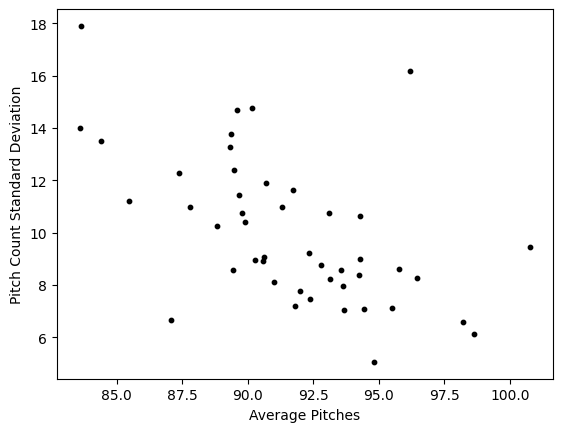

In [ ]:
volume_pitchers = workload_rows(PitchCounts, min_total_pitches=2500)
print_workload_summary(volume_pitchers)

for row in volume_pitchers.itertuples(index=False):
    plt.scatter(row.avg_pitches, row.pitch_count_sd, color="black", s=10.0)

plt.xlabel("Average Pitches")
plt.ylabel("Pitch Count Standard Deviation")
plt.show()


## Start-by-Start Shape

The final view overlays each 2,000-plus-pitcher's game-by-game pitch counts to show workload ramps, interruptions, and late-season usage changes.


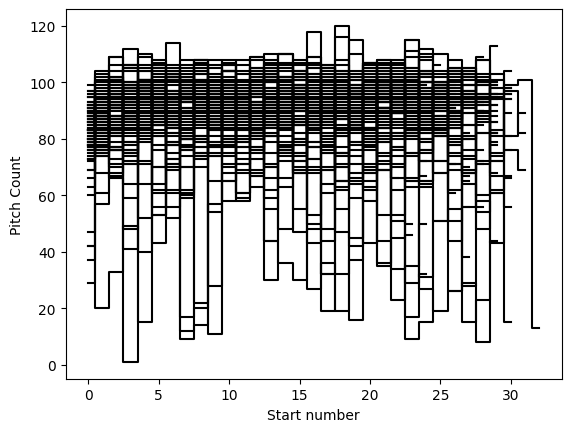

In [ ]:
starter_pool = workload_rows(PitchCounts, min_total_pitches=2000)

for row in starter_pool.itertuples(index=False):
    plt.plot(
        list(PitchCounts[row.team][row.pitcher].values()),
        color="black",
        drawstyle="steps-mid",
    )

plt.xlabel("Start number")
plt.ylabel("Pitch Count")
plt.show()
